# Quantum Teleportation and Superdense Coding

# Setup

We will use Qiskit and the Aer simulator.

If Qiskit is already installed, skip the installation line.


In [1]:
# If required, uncomment:
# %pip install qiskit qiskit-aer matplotlib

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity
from qiskit.visualization import plot_histogram

simulator = AerSimulator()


# Part A — Preparing and Understanding the Input Qubit

## Why do we start here?

In quantum teleportation, Alice is not teleporting a classical 0 or 1. She wants to transfer an **unknown quantum state**.

A general pure qubit can be written as

$$
|\psi\rangle=\alpha|0\rangle+\beta|1\rangle,
$$

where

$$
|\alpha|^2+|\beta|^2=1.
$$

For the first exercise, we deliberately use a simple **non-50/50 superposition**:

$$
\boxed{
|\psi\rangle=
\frac{\sqrt3}{2}|0\rangle+
\frac12|1\rangle
}
$$

This state is useful because the amplitudes are simple, but the probabilities are not equal.

The measurement probabilities are

$$
P(0)=|\alpha|^2=\frac34,
\qquad
P(1)=|\beta|^2=\frac14.
$$

Therefore,

$$
\boxed{P(0)=75\%,\qquad P(1)=25\%}.
$$

### How do we prepare it?

Starting from $|0\rangle$, use an $R_y(\theta)$ rotation:

$$
R_y(\theta)
=
\begin{pmatrix}
\cos(\theta/2)&-\sin(\theta/2)\\
\sin(\theta/2)&\cos(\theta/2)
\end{pmatrix}.
$$

Since

$$
R_y(\theta)|0\rangle
=
\cos\left(\frac\theta2\right)|0\rangle+
\sin\left(\frac\theta2\right)|1\rangle,
$$

choosing

$$
\theta=\frac\pi3
$$

gives

$$
R_y(\pi/3)|0\rangle
=
\frac{\sqrt3}{2}|0\rangle+
\frac12|1\rangle.
$$

This is our input state for the teleportation protocol.


## Exercise 1 — Prepare the non-uniform input state

Prepare

$$
|\psi\rangle=
\frac{\sqrt3}{2}|0\rangle+
\frac12|1\rangle.
$$

### Tasks

1. Create a one-qubit circuit.
2. Apply $R_y(\pi/3)$.
3. Draw the circuit.
4. Obtain the exact statevector.
5. Measure the qubit for 2000 shots.
6. Compare the experimental frequencies with the theoretical probabilities.

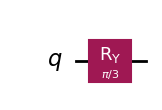

Statevector:
Statevector([0.8660254+0.j, 0.5      +0.j],
            dims=(2,))


In [2]:
theta = np.pi / 3

qc1 = QuantumCircuit(1)
qc1.ry(theta, 0)

# Display circuit
display(qc1.draw("mpl"))

print("Statevector:")
print(Statevector(qc1))


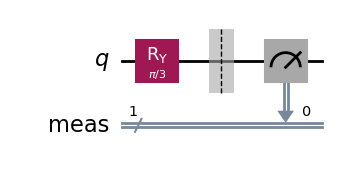

Counts: {'0': 1524, '1': 476}


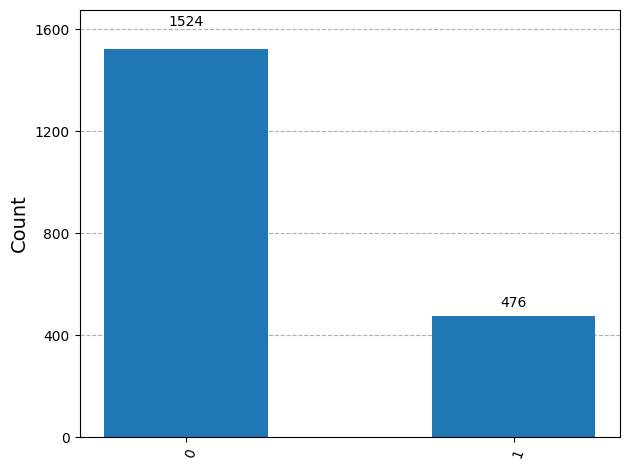

In [3]:
# Measurement experiment
#we make a copy of our circuit. We do this because we want to add measurement without changing our original state-preparation circuit.
qc1_measure = qc1.copy()
#Now we add a measurement to the qubit
qc1_measure.measure_all()
display(qc1_measure.draw("mpl"))
#Note: When we measure the qubit, the superposition is converted into a definite classical outcome: either 0 or 1
#Now we ask the simulator to perform this experiment 2000 times.
result = simulator.run(
    transpile(qc1_measure, simulator),
    shots=2000
).result()
#One shot means one complete execution of the circuit. So 2000 shots means we prepare and measure the qubit 2000 times.
counts1 = result.get_counts()#This extracts the number of times each measurement outcome occurred.
print("Counts:", counts1)

fig = plot_histogram(counts1)
fig

### Note:

The statevector is

$$
\begin{pmatrix}
\sqrt3/2\\
1/2
\end{pmatrix},
$$

up to numerical precision.

The theoretical probabilities are

$$
P(0)=3/4=0.75,
\qquad
P(1)=1/4=0.25.
$$

With 2000 shots, we expect approximately 1500 measurements of 0 and 500 measurements of 1, although the exact numbers fluctuate because the experiment is probabilistic.

**Key message:** A quantum state is described by amplitudes; measurement converts those amplitudes into probabilities.


## Quantum Teleportation: A protocol for transmitting the exact quantum state of one qubit to a distant qubit —using a pre-shared entangled pair plus a classical message.


In [4]:
plus = QuantumCircuit(1, 1)
plus.h(0)
plus.h(0)
plus.measure(0, 0)

minus = QuantumCircuit(1, 1)
minus.h(0)
minus.z(0)
minus.h(0)
minus.measure(0, 0)

r_plus = simulator.run(transpile(plus, simulator), shots=1000).result()
r_minus = simulator.run(transpile(minus, simulator), shots=1000).result()

print("|+> then H:", r_plus.get_counts())
print("|-> then H:", r_minus.get_counts())


|+> then H: {'0': 1000}
|-> then H: {'1': 1000}


### Solution 2

For $|+\rangle$:

$$
H|+\rangle=|0\rangle,
$$

so the result is approximately

```text
0: 1000
```

For $|-\rangle$:

$$
H|-\rangle=|1\rangle,
$$

so the result is approximately

```text
1: 1000
```

Thus, the phase difference is physically meaningful.

This is why teleportation cannot be verified merely by checking that Bob gets the same 0/1 measurement probabilities in one basis.


# Part B — Building the Bell Pair

## Entanglement resource

Teleportation and superdense coding both require a shared entangled pair.

Starting from

$$
|00\rangle,
$$

apply $H$ to the first qubit:

$$
|00\rangle
\xrightarrow{H\otimes I}
\frac{|00\rangle+|10\rangle}{\sqrt2}.
$$

Then apply CNOT:

$$
\frac{|00\rangle+|10\rangle}{\sqrt2}
\xrightarrow{CX}
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

This is a Bell state. The two qubits are now entangled, and Alice and Bob can each keep one qubit of this pair.

$$
|\Phi^+\rangle=
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$


## Exercise 2 — Create and verify a Bell state

Create

$$
|\Phi^+\rangle=
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

### Tasks

1. Create a two-qubit circuit.
2. Apply `H` to qubit 0.
3. Apply `CX(0,1)`.
4. Inspect the statevector.
5. Measure both qubits 1000 times.

### Questions

- Which computational-basis outcomes appear?
- Why do `01` and `10` not appear in the ideal simulation?
- Does observing only `00` and `11` by itself prove entanglement?


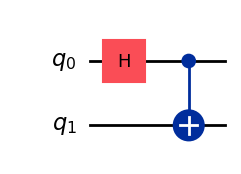

Bell state:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
Counts: {'00': 510, '11': 490}


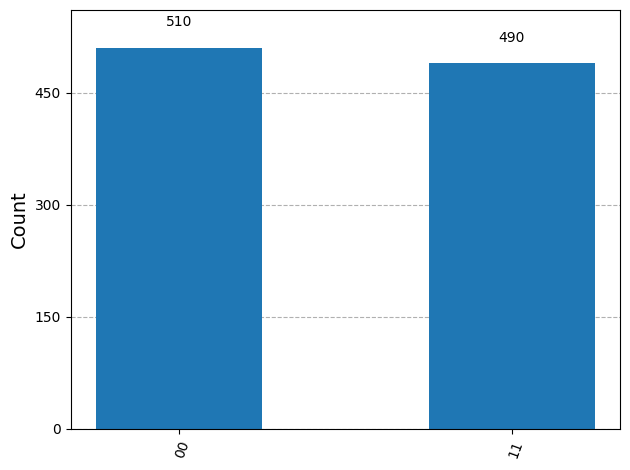

In [5]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

# Display circuit
display(bell.draw("mpl"))

bell_state = Statevector(bell)
print("Bell state:")
print(bell_state)

bell_measure = bell.copy()
bell_measure.measure_all()

bell_result = simulator.run(
    transpile(bell_measure, simulator),
    shots=1000
).result()

bell_counts = bell_result.get_counts()
print("Counts:", bell_counts)


fig = plot_histogram(bell_counts)
fig

### Note:

The statevector is

$$
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

Therefore,

$$
P(00)=\frac12,
\qquad
P(11)=\frac12,
$$

and

$$
P(01)=P(10)=0.
$$


# Part C — Quantum Teleportation

## What are we trying to accomplish?

Alice possesses

$$
|\psi\rangle=\alpha|0\rangle+\beta|1\rangle.
$$

Bob should end up with the same unknown state.

Alice and Bob initially share

$$
|\Phi^+\rangle_{AB}
=
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

The three-qubit initial state is therefore

$$
|\psi\rangle_1\otimes|\Phi^+\rangle_{23}.
$$

Alice performs a Bell-basis measurement on her two qubits. The combined state can be rewritten as

$$
\begin{aligned}
|\psi\rangle|\Phi^+\rangle
=\frac12[
&|00\rangle|\psi\rangle
+|01\rangle X|\psi\rangle\\
&+|10\rangle Z|\psi\rangle
+|11\rangle XZ|\psi\rangle
].
\end{aligned}
$$

This equation is the heart of teleportation.

Alice's two measurement bits tell Bob **which version of the state he has**. Bob then applies the appropriate correction:

| Alice's result | Bob's state before correction | Bob applies |
|---|---|---|
| 00 | $|\psi\rangle$ | $I$ |
| 01 | $X|\psi\rangle$ | $X$ |
| 10 | $Z|\psi\rangle$ | $Z$ |
| 11 | $XZ|\psi\rangle$ | $ZX$ |

After correction, Bob has

$$
|\psi\rangle.
$$


## Exercise 3 — Build the teleportation circuit step by step

### The complete teleportation circuit

Use the following circuit as a guide while building the circuit in Qiskit:

```text
             Alice                              Bob

q₀: |ψ⟩ ─────●────H────M──────────────
             │         │
q₁: |0⟩ ──H──⊕────M───┼──────────────
          │  Bell      │
q₂: |0⟩ ──⊕── pair     │────Z────X─── |ψ⟩
                       │     ↑    ↑
                       └─────┴────┴── classical bits
```

The circuit consists of four stages:

$$
\boxed{\text{Prepare }|\psi\rangle}
\rightarrow
\boxed{\text{Create Bell pair}}
\rightarrow
\boxed{\text{Alice's measurement}}
\rightarrow
\boxed{\text{Bob's correction}}
$$

Alice has two qubits:

$q_0$: the state she wants to transfer

$q_1$: her half of the entangled pair

Bob has $q_2$, the other half of the entangled pair. 

Use two classical bits for Alice's measurement.

### Step 1 — Prepare Alice's state

$$
|\psi\rangle=
\frac{\sqrt3}{2}|0\rangle+
\frac12|1\rangle.
$$

### Step 2 — Create the Bell pair

Apply

$$
H(q_1)
$$

and

$$
CX(q_1,q_2).
$$

### Step 3 — Bell-basis measurement

Apply

$$
CX(q_0,q_1)
$$

followed by

$$
H(q_0).
$$

Then measure $q_0$ and $q_1$.

### Step 4 — Bob's corrections

The measurement results determine which correction Bob applies:

| Alice's result | Bob applies |
| -------------- | ----------- |
| \(00\)         | \(I\)       |
| \(01\)         | \(X\)       |
| \(10\)         | \(Z\)       |
| \(11\)         | \(XZ\)      |

Apply:

- $X$ if the second classical bit is 1;
- $Z$ if the first classical bit is 1.

### Task

Complete and run the circuit for 2000 shots.


In [6]:
# Create 3 qubits:
# q[0] → Alice's state to be teleported
# q[1] → Alice's half of the Bell pair
# q[2] → Bob's half of the Bell pair
q = QuantumRegister(3, "q")#Create a quantum register containing 3 qubits, q is simply the name we give to our quantum register

# Two classical bits to store Alice's measurement results
c = ClassicalRegister(2, "c")

# Create the teleportation circuit

teleport = QuantumCircuit(q, c)#Create a quantum circuit that contains the quantum register q and the classical register c

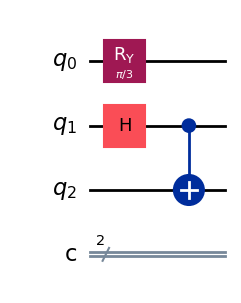

In [7]:

# ============================================================
# Step 1 — Prepare Alice's input state
# |ψ⟩ = √3/2 |0⟩ + 1/2 |1⟩
# ============================================================
teleport.ry(np.pi / 3, q[0])


# ============================================================
# Step 2 — Create the shared Bell pair
# Alice keeps q[1] and Bob keeps q[2]
# H followed by CNOT creates:
# |Φ⁺⟩ = (|00⟩ + |11⟩) / √2
# ============================================================
teleport.h(q[1])
teleport.cx(q[1], q[2])
display(teleport.draw("mpl"))

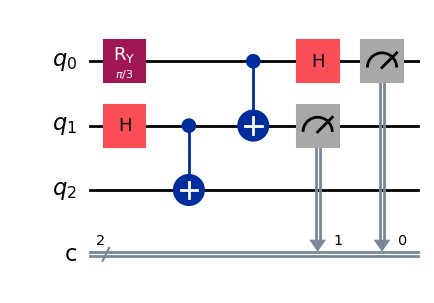

In [8]:
# ============================================================
# Step 3 — Alice's Bell-basis measurement
# Apply CNOT and H to Alice's two qubits
# ============================================================
#Alice first applies a CNOT between her two qubits. This combines the information in her input qubit with her half of the entangled pair.
teleport.cx(q[0], q[1])
#She then applies a Hadamard to q_0. Together, these two gates prepare Alice's two qubits for a Bell-basis measurement
teleport.h(q[0])

#Alice now measures both of her qubits. The two measurement results are stored in the classical bits c_0 and c_1.
# q[0] → c[0]: Measure qubit q[0], and put the measurement result into classical bit c[0]
# q[1] → c[1]: SAME 
teleport.measure(q[0], c[0])
teleport.measure(q[1], c[1])
display(teleport.draw("mpl"))

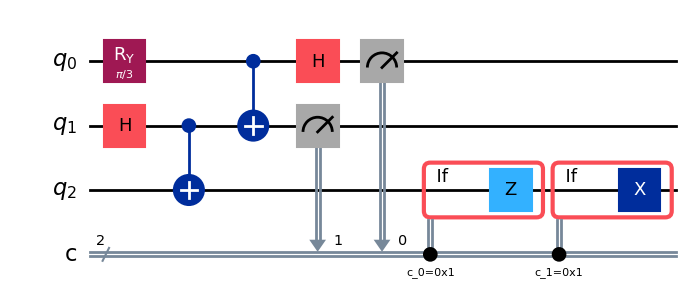

In [9]:

# ============================================================
# Step 4 — Bob's classically controlled corrections
#Alice measures q_0 and q_1, and stores the two results in c_0 and c_1.
#Together, c_0c_1 give one of four possible results: 00, 01, 10, or 11. Bob uses these two classical bits to decide which correction to apply.
# If c[1] = 1 → apply X to Bob's qubit q[2]
# If c[0] = 1 → apply Z to Bob's qubit q[2]
#
# This implements:
# 00 → I
# 01 → X
# 10 → Z
# 11 → XZ
# ============================================================

# If c[0] = 1, apply Z to Bob's qubit
with teleport.if_test((c[0], 1)):
    teleport.z(q[2])

# If c[1] = 1, apply X to Bob's qubit
with teleport.if_test((c[1], 1)):
    teleport.x(q[2])
# ============================================================
# Display the complete teleportation circuit
# ============================================================
display(teleport.draw("mpl"))

In [10]:

# ============================================================
# Run the teleportation experiment
# ============================================================
teleport_result = simulator.run(
    transpile(teleport, simulator),
    shots=2000
).result()#classical measurement outcomes stored in the classical register (c0,c1)

# Get Alice's two-bit measurement outcomes
teleport_counts = teleport_result.get_counts()

{'11': 517, '10': 498, '00': 507, '01': 478}


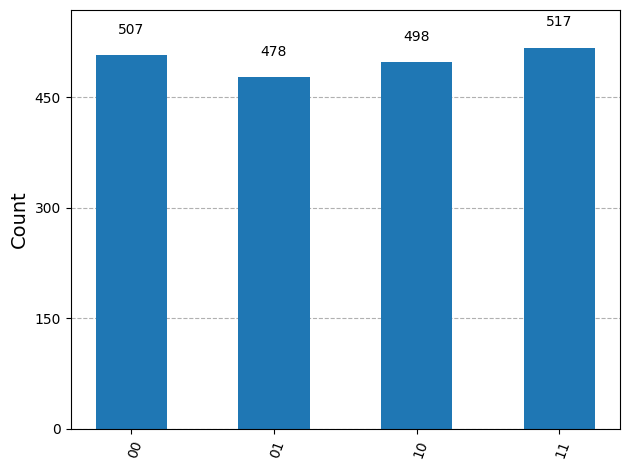

In [11]:
# Display Alice's four teleportation outcomes
print(teleport_counts)

fig = plot_histogram(teleport_counts)
display(fig)
##is mainly showing Alice's four classical measurement outcomes. It does not yet directly verify that Bob has \(|\psi\rangle\).
#The theoretical expectation is: P(00)=P(01)=P(10)=P(11)=1/4.

#With 2000 shots: 2000/4=500. These results are close to 500 because of statistical fluctuations.

## Observation —  

The circuit produces four possible outcomes for Alice's two classical bits:

$$
00,\quad 01,\quad 10,\quad 11.
$$

These outcomes occur with approximately equal probability. The particular outcome is random, but it determines the correction Bob applies to his qubit:

$$
00 \rightarrow I,
\qquad
01 \rightarrow X,
\qquad
10 \rightarrow Z,
\qquad
11 \rightarrow Z\text{ followed by }X.
$$

Thus, Alice's two classical measurement bits tell Bob which correction is required to recover the state that Alice prepared.

## Takeaway — Quantum Teleportation

We started with a quantum state prepared by Alice:

$$
|\psi\rangle=
\frac{\sqrt3}{2}|0\rangle+\frac12|1\rangle.
$$

Alice and Bob then shared an entangled Bell pair. Alice performed a
Bell-basis measurement on her two qubits and obtained two classical bits.
These bits determined the correction that Bob applied to his qubit.

Thus, the teleportation protocol can be summarized as:

$$
\boxed{
\text{Quantum state}
\rightarrow
\text{Entanglement}
\rightarrow
\text{Measurement}
\rightarrow
\text{Classical bits}
\rightarrow
\text{Correction}
}
$$

The important idea is that **the quantum state is transferred to Bob's
qubit without physically sending Alice's original qubit**.

> **Key takeaway:** Quantum teleportation uses entanglement together with
> classical communication to transfer an unknown quantum state.

## Exercise 4 (to be tried on your own)— Verify Bob's teleported state

The previous circuit measured Alice's two qubits but did not directly measure Bob's final state.

For each possible Alice outcome, construct the corresponding post-measurement branch, apply Bob's correction, and compare Bob's state with the original input.


# Part E — Superdense Coding

## Motivation

In quantum teleportation, we used a shared entangled pair to transfer a quantum state using classical communication.  

Now, let's look at a related but almost opposite problem: instead of transferring a quantum state using two classical bits, can we use one shared entangled pair to send two classical bits? This is the idea behind Superdense coding.

## The communication problem

Suppose Alice wants to send one of four classical messages:

$$
00,\quad01,\quad10,\quad11.
$$

Classically, two bits are required.

Superdense coding shows that if Alice and Bob already share an entangled Bell pair, Alice can send **two classical bits by physically transmitting only one qubit**.

They start with

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

Alice applies one of four operations to her qubit:

| Message | Alice applies | Resulting Bell state |
|---|---|---|
| 00 | $I$ | $|\Phi^+\rangle$ |
| 01 | $X$ | $|\Psi^+\rangle$ |
| 10 | $Z$ | $|\Phi^-\rangle$ |
| 11 | $XZ$ | $|\Psi^-\rangle$ |

where

$$
|\Psi^+\rangle=
\frac{|01\rangle+|10\rangle}{\sqrt2},
$$

$$
|\Phi^-\rangle=
\frac{|00\rangle-|11\rangle}{\sqrt2},
$$

and

$$
|\Psi^-\rangle=
\frac{|01\rangle-|10\rangle}{\sqrt2}.
$$

Bob then performs the inverse Bell-state transformation:

$$
CX
$$

followed by

$$
H.
$$

The Bell states are converted into the computational basis states, allowing Bob to read Alice's two-bit message.


## Exercise 5 — Create the shared Bell pair

Alice and Bob begin by sharing an entangled Bell pair:

$$
|\Phi^+\rangle=
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

Use two qubits:

- $q_0$: Alice's qubit
- $q_1$: Bob's qubit

Starting from

$$
|00\rangle,
$$

create the Bell state using:

$$
H(q_0)
$$

followed by

$$
CX(q_0,q_1).
$$

### Task

Build and draw the circuit.

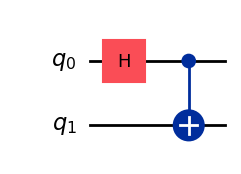

In [15]:
# Create two qubits:
# q[0] → Alice's qubit
# q[1] → Bob's qubit
q = QuantumRegister(2, "q")

# Create a quantum circuit
dense = QuantumCircuit(q)

# Create the shared Bell pair
dense.h(q[0])
dense.cx(q[0], q[1])

# Display the circuit
display(dense.draw("mpl"))

## This is exactly the Bell-pair preparation we used in teleportation. Alice has \(q_0\), Bob has \(q_1\), and the two qubits are now entangled.
##  The important difference is what happens next. In teleportation, Alice used her qubits to transfer a quantum state. Here, Alice will use her qubit to encode a classical message

## Exercise 7 — Encode Alice's message

Alice wants to send one of four messages:

$$
00,\quad01,\quad10,\quad11.
$$

She encodes the message by applying a gate to her qubit $q_0$:

| Message | Gate applied by Alice |
|---|---|
| $00$ | $I$ |
| $01$ | $X$ |
| $10$ | $Z$ |
| $11$ | $XZ$ |

For this exercise, choose one message and apply the corresponding gate
to Alice's qubit.

### Task

1. Choose a message.
2. Apply the corresponding operation to $q_0$.
3. Draw the circuit.
4. Repeat for all four messages.

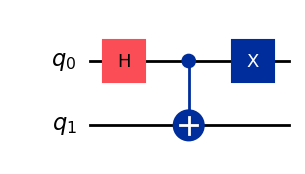

In [24]:
# Choose Alice's message
message = "01"

# Start with the shared Bell pair
dense = QuantumCircuit(2)

# Create |Φ⁺⟩
dense.h(0)
dense.cx(0, 1)

# Alice encodes her message on q[0]
if message == "00":
    pass                  # Apply I: do nothing

elif message == "01":
    dense.x(0)            # Apply X

elif message == "10":
    dense.z(0)            # Apply Z

elif message == "11":
    dense.x(0)            # Apply X
    dense.z(0)            # Apply Z

# Display the circuit
display(dense.draw("mpl"))
#Alice doesn't need to send two qubits. She changes her half of the entangled pair according to the two-bit message she wants to send.
#Alice now physically sends her one qubit to Bob. Bob will then have both qubits and try to determine which message Alice encoded

## Exercise 8 — Bob decodes Alice's message

After Alice encodes her message, she sends her qubit to Bob.
Bob now has both qubits.

To identify the Bell state, Bob applies the inverse Bell-state transformation:

$$
CX(q_0,q_1)
$$

followed by

$$
H(q_0).
$$

These operations convert the four Bell states into the corresponding
computational-basis states.

Finally, Bob measures both qubits.

### Task

Choose one of the four messages from Exercise 7, complete the decoding
circuit, and verify that Bob recovers the same two-bit message.

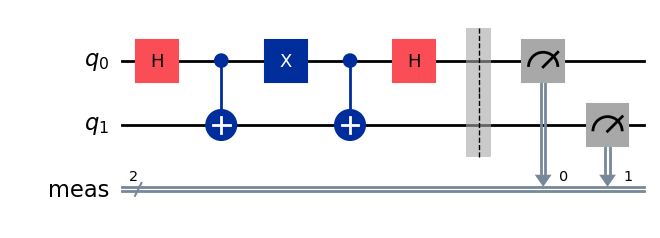

Alice sent   : 01
Bob recieved  : 01


In [28]:
# Choose Alice's message
message = "01"

# Create the encoded Bell state
qc = encoded_bell_state(message)

# Bob decodes the Bell state
qc.cx(0, 1)
qc.h(0)

# Add two classical bits for measurement
qc.measure_all()

# Display the decoding circuit
display(qc.draw("mpl"))

# Run the circuit
result = simulator.run(
    transpile(qc, simulator),
    shots=2000
).result()

counts = result.get_counts()
# print("Alice sent:", message)
# print("Bob received:", counts)
# Qiskit displays the classical bits in reverse order.
# Reverse the bitstring so it matches our message convention c0c1.
decoded_message = next(iter(counts))[::-1]

print("Alice sent   :", message)
print("Bob recieved  :", decoded_message)


plot_histogram(counts)
plt.show()

### Observation

Bob's measurement reproduces the message chosen by Alice.

Thus, the complete protocol is:

$$
\boxed{
\text{Entanglement}
\rightarrow
\text{Alice encodes 2 bits}
\rightarrow
\text{1 qubit is sent}
\rightarrow
\text{Bob decodes 2 bits}
}
$$

The shared entangled pair is the resource that makes this possible.


## Teleportation vs. Superdense Coding

The two protocols are closely related but accomplish opposite communication tasks.

| Resource / feature | Teleportation | Superdense coding |
|---|---|---|
| Main goal | Transfer an unknown qubit state | Send two classical bits |
| Shared Bell pair | Yes | Yes |
| Qubits physically sent | 0 quantum states from Alice's original qubit; 2 classical bits are sent | 1 qubit |
| Classical bits sent | 2 | 0 during the encoding/decoding step |
| Information being communicated | Quantum state | Classical message |
| Alice measures? | Yes | No |
| Bob performs correction? | Yes | Bell-state decoding |
| No-cloning principle relevant? | Yes | Not the central point |

### The cleanest way to remember them

**Teleportation:**

$$
\boxed{
1\ \text{qubit state}
\longrightarrow
2\ \text{classical bits + shared entanglement}
}
$$

with Bob reconstructing the quantum state.

**Superdense coding:**

$$
\boxed{
2\ \text{classical bits}
\longrightarrow
1\ \text{transmitted qubit + shared entanglement}
}
$$

The protocols are therefore often described as complementary demonstrations of the communication power of entanglement.
